In [2]:
import matplotlib.pyplot as plt
import numpy as np
import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

g:\software\anaconda\envs\pytorch\Lib\site-packages\torch\cuda\__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [3]:
model_path = "G:/model_weights/models/model/qwen2.5-7B-Instruct"
model = AutoModelForCausalLM.from_pretrained(model_path).to('cuda')
tokenizer = AutoTokenizer.from_pretrained(model_path)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [4]:
print(model)

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(152064, 3584)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=3584, out_features=3584, bias=True)
          (k_proj): Linear(in_features=3584, out_features=512, bias=True)
          (v_proj): Linear(in_features=3584, out_features=512, bias=True)
          (o_proj): Linear(in_features=3584, out_features=3584, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=3584, out_features=18944, bias=False)
          (up_proj): Linear(in_features=3584, out_features=18944, bias=False)
          (down_proj): Linear(in_features=18944, out_features=3584, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((3584,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((3584,), eps=1e-06)
    (ro

In [7]:
prompt = "盖伦朝着诺克萨斯之手，快速的Q"
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
inputs

{'input_ids': tensor([[ 99758, 100794, 108116, 101176,  99316, 100841,  99295,  53930,  44934,
           3837, 101098,   9370,     48]], device='cuda:0'), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]], device='cuda:0')}

In [8]:
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
print(logits.shape)

torch.Size([1, 13, 152064])


In [9]:
last_logits = logits[0, -1, :]
next_token_id = last_logits.argmax()
next_token_id

tensor(101139, device='cuda:0')

In [10]:
tokenizer.decode(next_token_id)

'技能'

In [11]:
topk = torch.topk(last_logits, k=10)
tokens = [tokenizer.decode([tk]) for tk in topk.indices]
tokens

['技能', 'W', '了', '出了', '了一下', '闪', '到了', '到', '出', '-']

In [13]:
next_inputs = {
    "input_ids": torch.cat(
        [inputs["input_ids"], next_token_id.reshape((1, 1))], dim=1
    ), 
    "attention_mask": torch.cat(
        [inputs["attention_mask"], torch.tensor([[1]]).to("cuda")], dim=1
    )
}

In [14]:
torch.tensor([1]).unsqueeze(1)

tensor([[1]])

In [15]:
def generate_token(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits[0, -1, :]
    next_token_id = logits.argmax()
    return  next_token_id

In [17]:
generate_tokens = []
next_inputs = inputs
durations_s = []
for _ in range(10):
    t0 = time.time()
    next_token_id = generate_token(next_inputs)
    durations_s += [time.time() - t0]

    next_inputs = {
        "input_ids": torch.cat(
            [inputs["input_ids"], next_token_id.reshape((1, 1))], dim=1
        ), 
        "attention_mask": torch.cat(
            [inputs["attention_mask"], torch.tensor([[1]]).to("cuda")], dim=1
        )
    }
    next_token = tokenizer.decode(next_token_id)
    generate_tokens.append(next_token)

[0.19440984725952148, 0.04400062561035156, 0.03240370750427246, 0.03977847099304199, 0.03539133071899414, 0.03503680229187012, 0.03438591957092285, 0.032913923263549805, 0.02878284454345703, 0.05623793601989746]


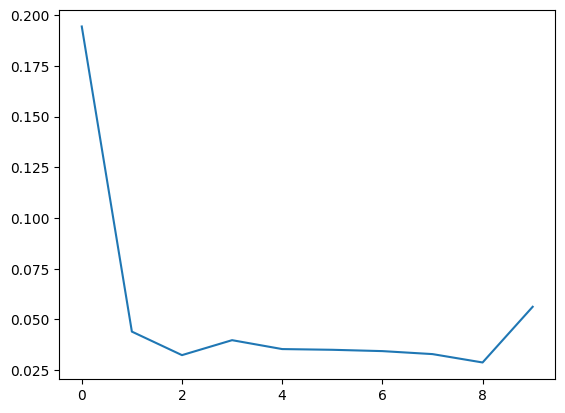

In [18]:
print(durations_s)
plt.plot(durations_s)

In [19]:
def generate_token_with_past(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    last_logits = logits[0, -1, :]
    next_token_id = last_logits.argmax()
    return next_token_id, outputs.past_key_values

In [20]:
generate_tokens = []
next_inputs = inputs
durations_cached_s = []
for _ in range(10):
    t0 = time.time()
    next_token_id, past_key_values = generate_token_with_past(next_inputs)
    durations_cached_s += [time.time() - t0]

    next_inputs = {
        "input_ids":  next_token_id.reshape((1, 1)),
        "attention_mask": torch.cat(
            [inputs["attention_mask"], torch.tensor([[1]]).to("cuda")], dim=1
        ),
        "past_key_values": past_key_values
    }
    next_token = tokenizer.decode(next_token_id)
    generate_tokens.append(next_token)

[0.08049988746643066, 0.07716846466064453, 0.04876303672790527, 0.07949328422546387, 0.04796457290649414, 0.030371904373168945, 0.022912263870239258, 0.049608469009399414, 0.03815484046936035, 0.03332018852233887]


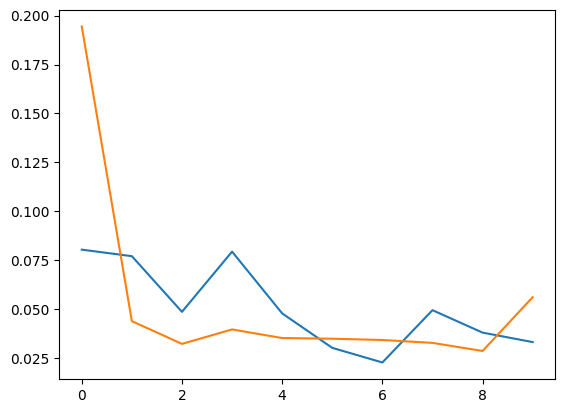

In [21]:
print(durations_cached_s)
plt.plot(durations_cached_s)
plt.plot(durations_s)